# Eksperyment: Wpływ Architektury (Warstwy i Neurony) na Wyniki MLP

W tym notatniku zbadano, jak zmiana liczby warstw ukrytych i neuronów wpływa na proces uczenia i ostateczną wydajność modelu MLP w zadaniu klasyfikacji wieloklasowej (5 klas, dane nieliniowe).

Wykorzystujemy najlepszą funkcję aktywacji (GELU) z poprzedniego eksperymentu.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.f2py.crackfortran import verbose

from mlp import MLP
from mlp.utils import plot_loss, plot_weight_evolution, plot_dataset, plot_decision_boundary, train_test_split, accuracy, mse, plot_predictions,load_dataset, plot_accuracy, plot_weights_together

# Konfiguracja bazowa
SEED = 44
np.random.seed(SEED)

# Ustaw ścieżkę do pliku CSV
# Upewnij się, że ten plik jest dostępny (np. w folderze '../lab1_data/Classification/')
CSV_PATH = "../../lab1_data/Classification/data.XOR.train.1000.csv"
TASK = "multiclass"
ACTIVATION = "gelu" 
LEARNING_RATE = 0.05
EPOCHS = 1000
USE_BIAS = True

# Wczytanie i przygotowanie danych
X, y = load_dataset(CSV_PATH)

N_FEATURES = X.shape[1]
# N_CLASSES = len(np.unique(y))
N_CLASSES = 1 if TASK == "regression" else len(np.unique(y))
Y_TARGET = y.reshape(-1, 1) # Używamy Y_TARGET w fit/loss, ale X, y w plotach
print(f"Dane wczytane. Cechy: {N_FEATURES}, Klasy: {N_CLASSES}")
print(f"Przykładowe etykiety: {np.unique(y)}")

Dane wczytane. Cechy: 2, Klasy: 2
Przykładowe etykiety: [0 1]


## Wizualizacja Danych

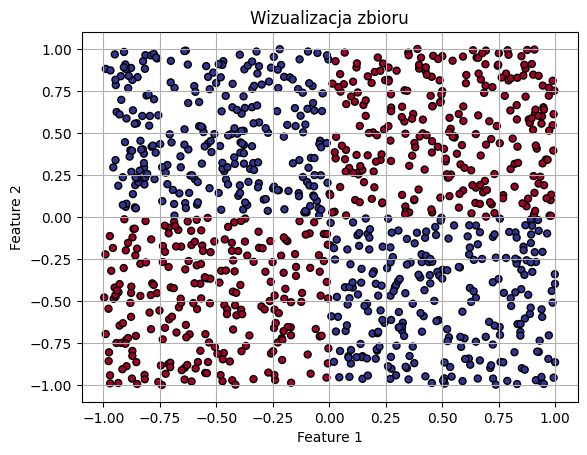

In [26]:
plot_dataset(X,y,"Wizualizacja zbioru")

## Konfiguracja i Trening Eksperymentów

--- Rozpoczynanie eksperymentów architektonicznych ---

=== Trening dla architektury: Shallow ([2, 2]) ===
X_test shape: (300, 2)
y_test shape: (300, 1)
preds_raw shape: (300, 1)
Końcowa strata (trening): 0.691029 | Dokładność (TEST): 0.4633
--- Generowanie wizualizacji ---


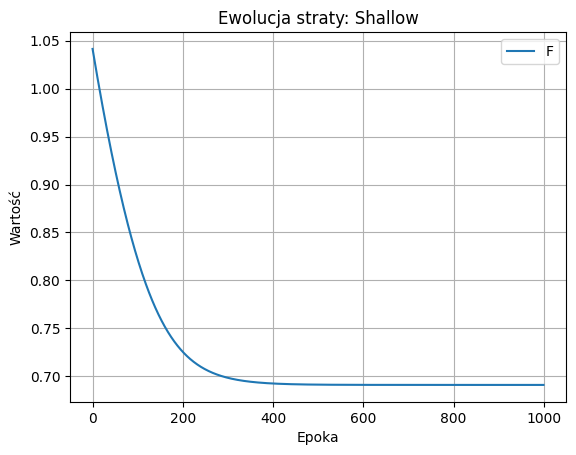

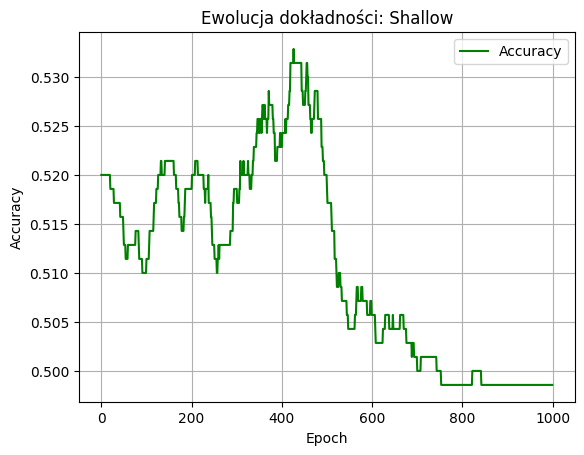

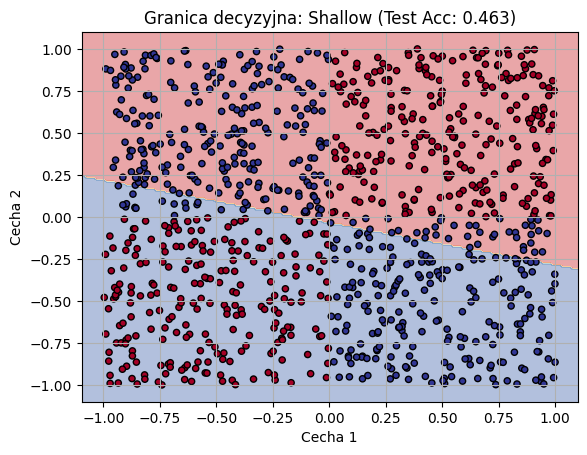

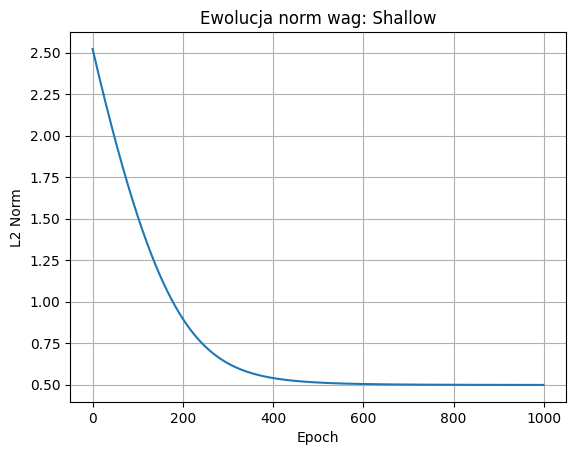


=== Trening dla architektury: Shallow_8 ([2, 8, 2]) ===
X_test shape: (300, 2)
y_test shape: (300, 1)
preds_raw shape: (300, 1)
Końcowa strata (trening): 0.131206 | Dokładność (TEST): 0.4633
--- Generowanie wizualizacji ---


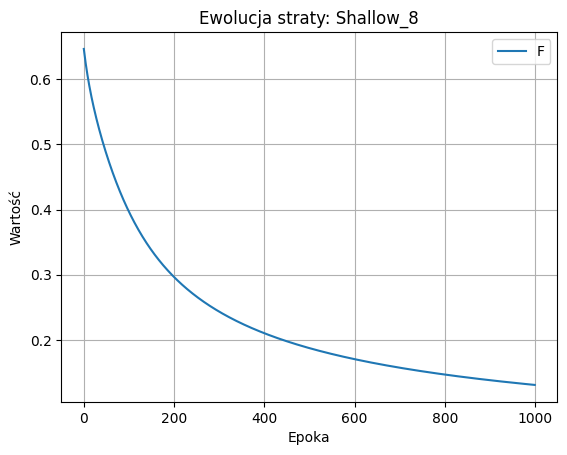

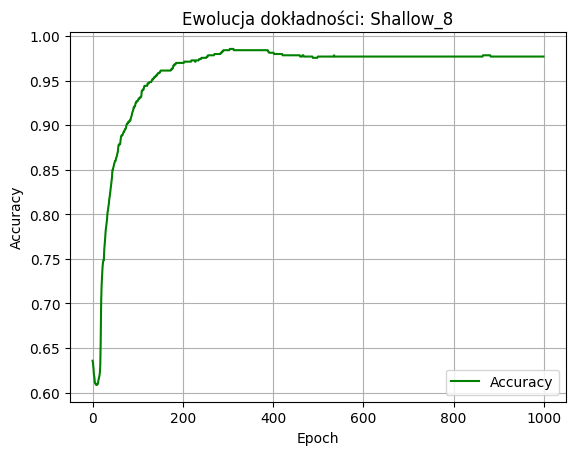

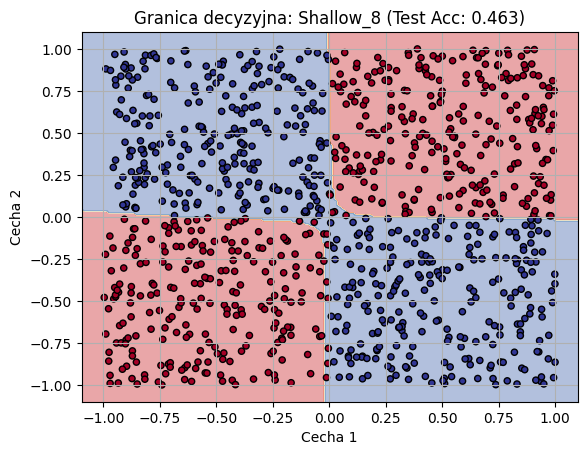

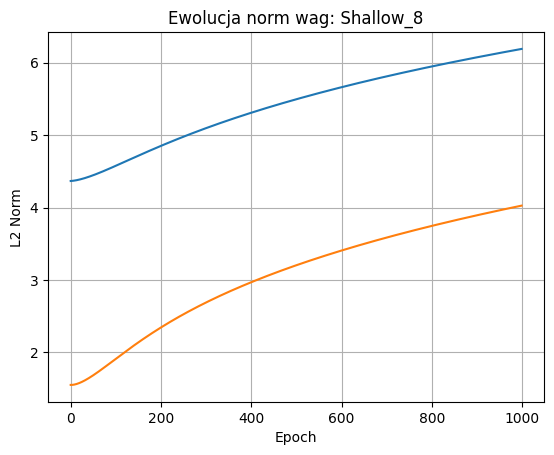


=== Trening dla architektury: Shallow_16 ([2, 16, 2]) ===
X_test shape: (300, 2)
y_test shape: (300, 1)
preds_raw shape: (300, 1)
Końcowa strata (trening): 0.140479 | Dokładność (TEST): 0.4633
--- Generowanie wizualizacji ---


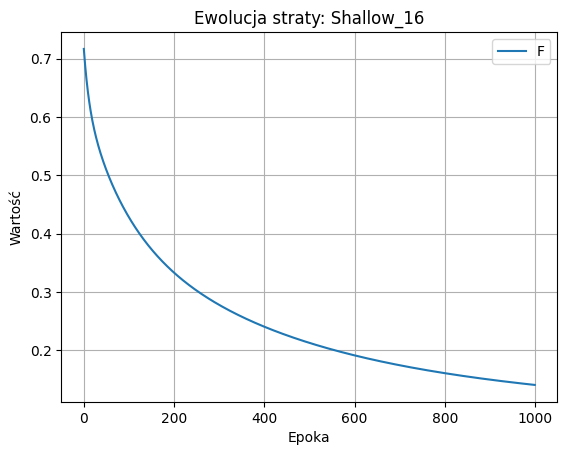

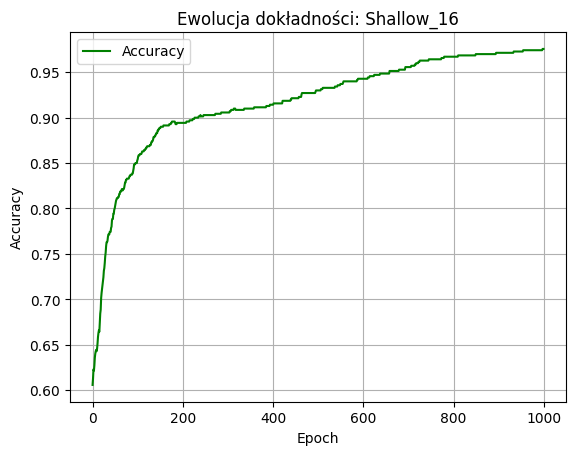

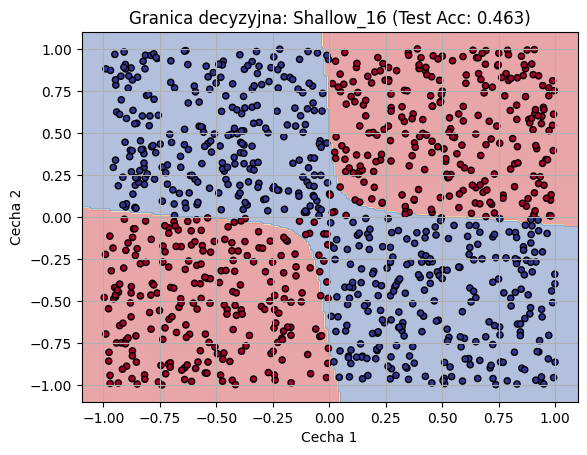

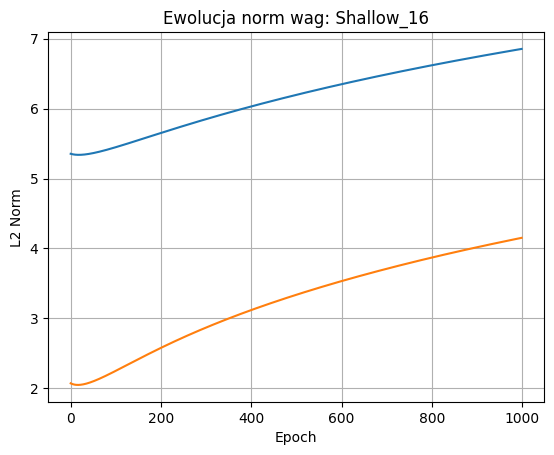


=== Trening dla architektury: Shallow_32 ([2, 32, 2]) ===
X_test shape: (300, 2)
y_test shape: (300, 1)
preds_raw shape: (300, 1)
Końcowa strata (trening): 0.121888 | Dokładność (TEST): 0.4633
--- Generowanie wizualizacji ---


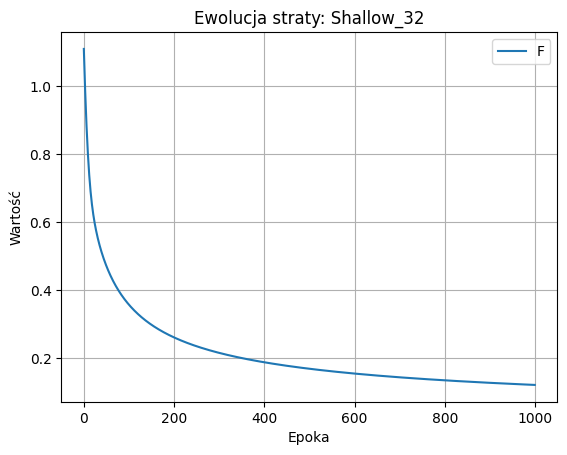

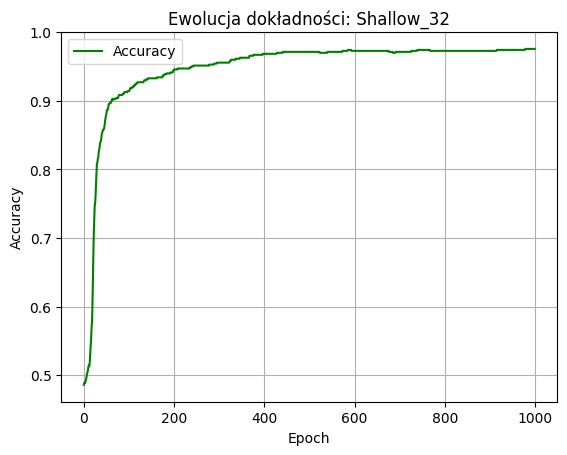

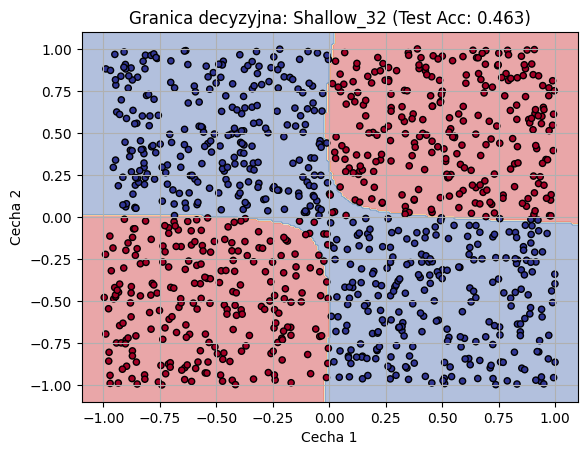

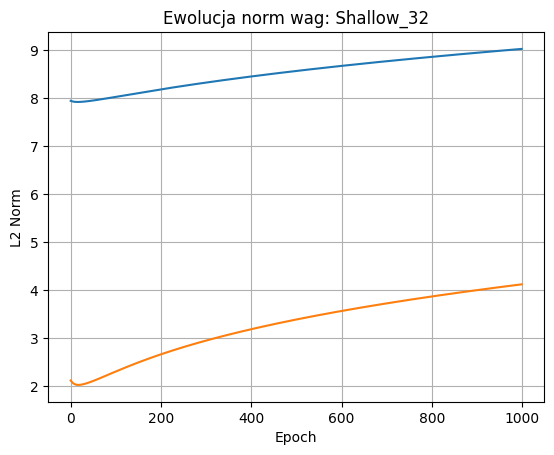


=== Trening dla architektury: Deep_8_8 ([2, 8, 8, 2]) ===
X_test shape: (300, 2)
y_test shape: (300, 1)
preds_raw shape: (300, 1)
Końcowa strata (trening): 0.063956 | Dokładność (TEST): 0.4633
--- Generowanie wizualizacji ---


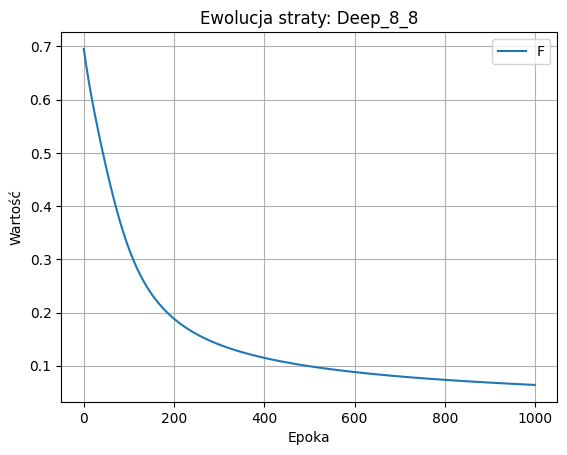

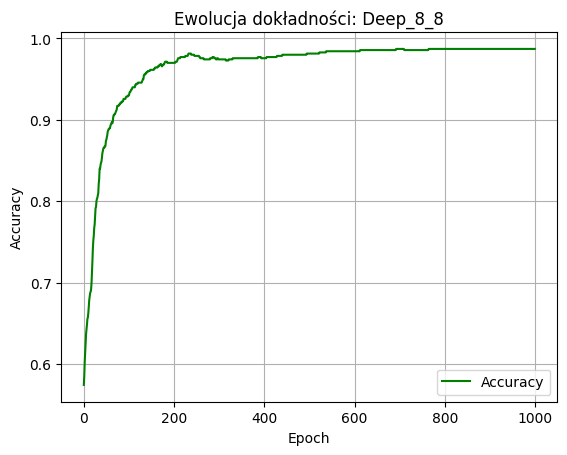

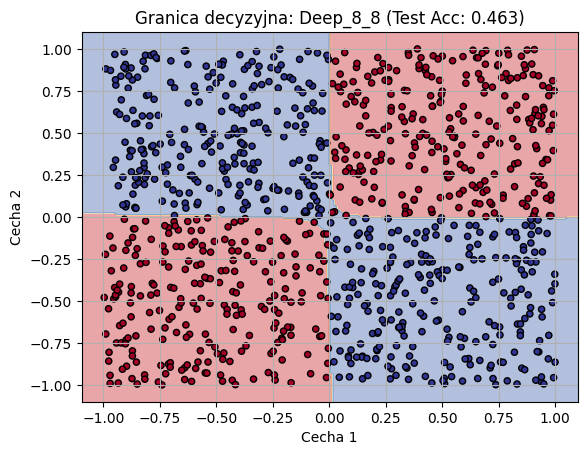

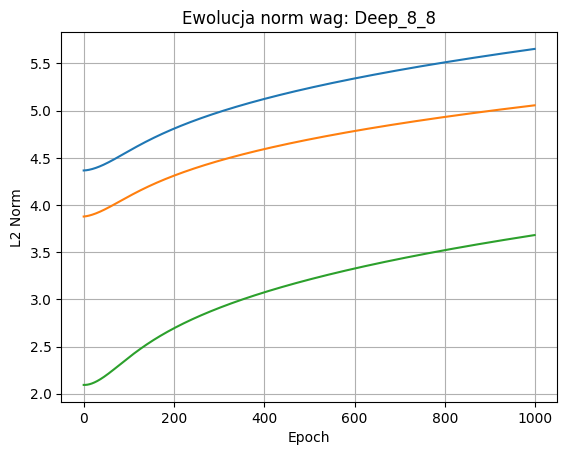


=== Trening dla architektury: Deep_16_8 ([2, 16, 8, 2]) ===
X_test shape: (300, 2)
y_test shape: (300, 1)
preds_raw shape: (300, 1)
Końcowa strata (trening): 0.067494 | Dokładność (TEST): 0.4633
--- Generowanie wizualizacji ---


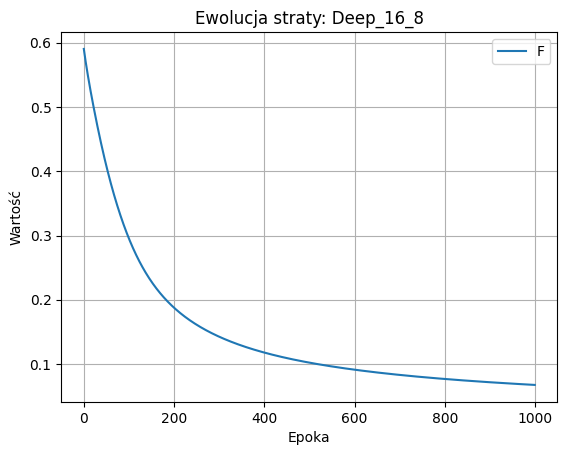

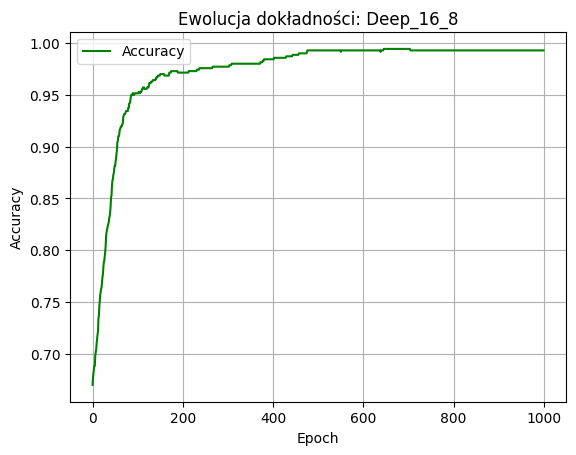

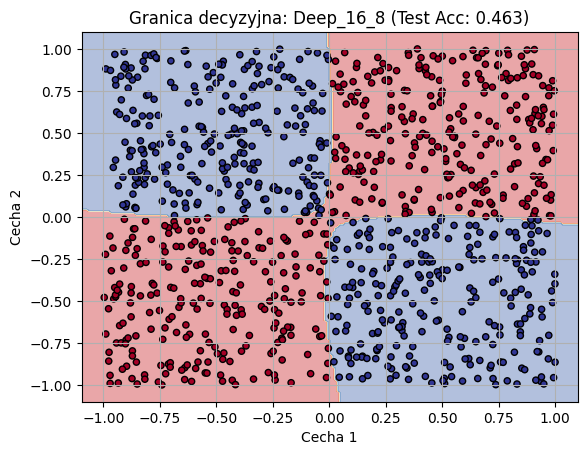

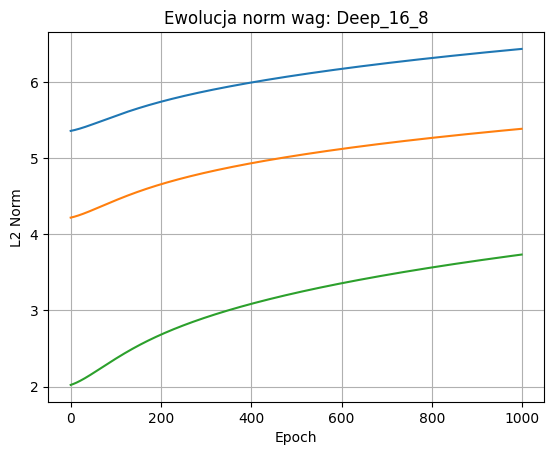


=== Trening dla architektury: Deep_16_16 ([2, 16, 16, 2]) ===
X_test shape: (300, 2)
y_test shape: (300, 1)
preds_raw shape: (300, 1)
Końcowa strata (trening): 0.067495 | Dokładność (TEST): 0.4633
--- Generowanie wizualizacji ---


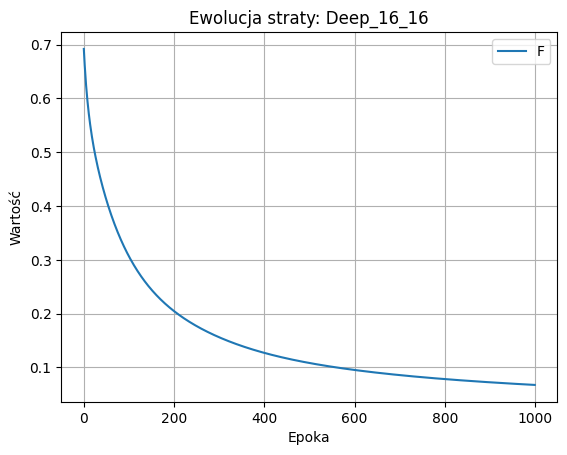

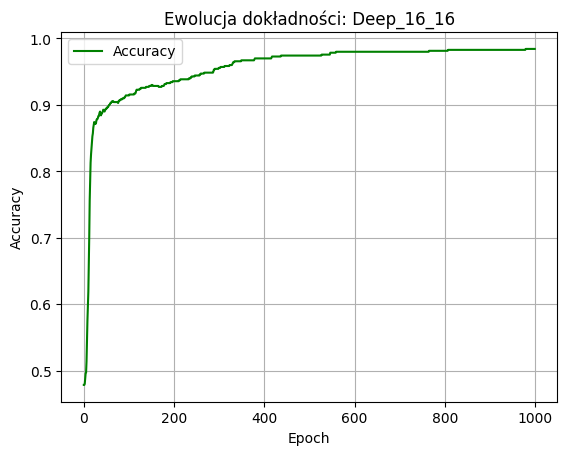

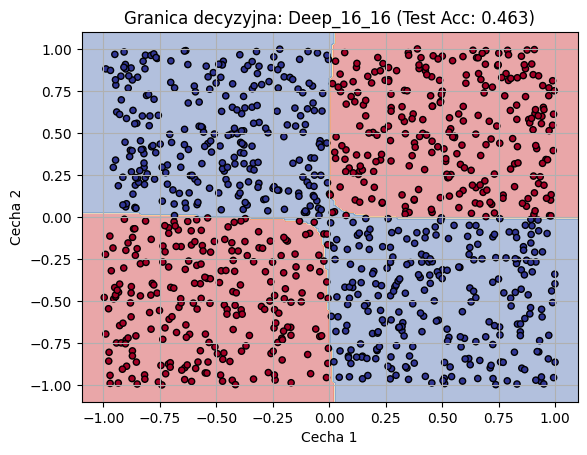

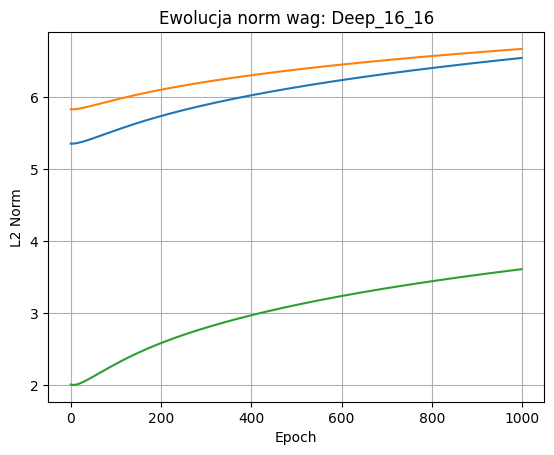


=== Trening dla architektury: Deep_32_64_64_32 ([2, 32, 64, 64, 32, 2]) ===
X_test shape: (300, 2)
y_test shape: (300, 1)
preds_raw shape: (300, 1)
Końcowa strata (trening): 0.021767 | Dokładność (TEST): 0.4633
--- Generowanie wizualizacji ---


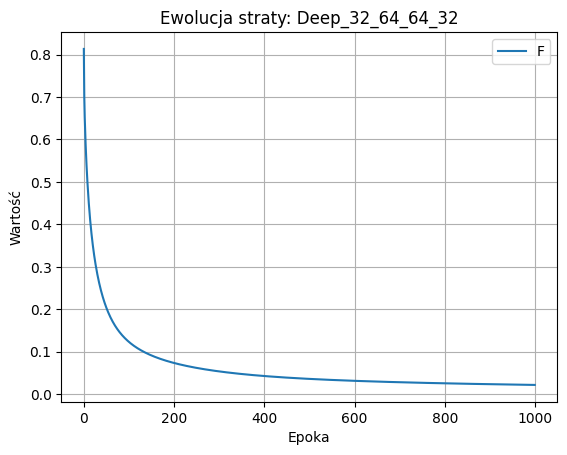

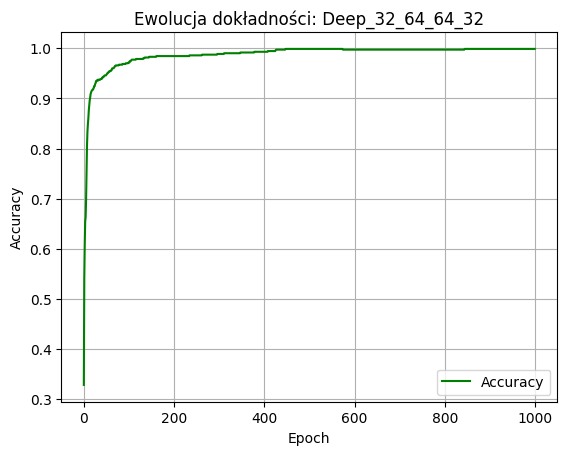

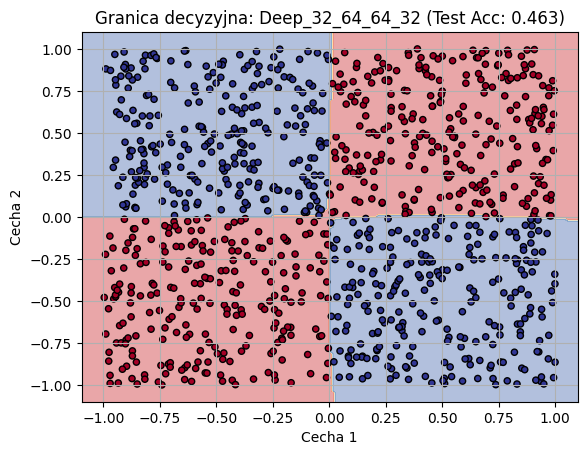

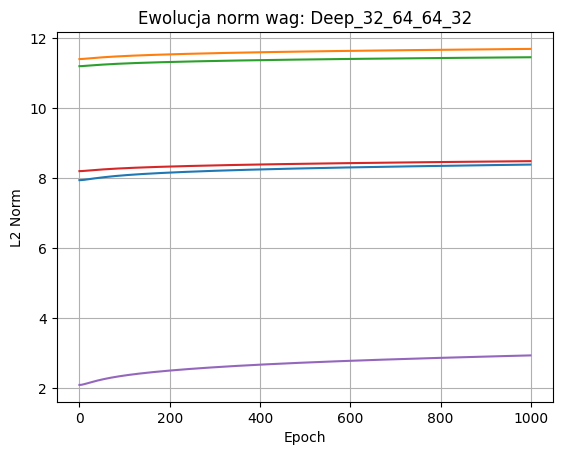


--- Zakończono eksperymenty ---


In [27]:
# Eksperymentalne architektury do porównania
# Format: { Nazwa: [Rozmiary Warstw] }
ARCHITECTURES = {
    # 1. Architektury Płytkie (Mniej warstw, różna liczba neuronów)
    "Shallow": [N_FEATURES,  N_CLASSES], 
    "Shallow_8": [N_FEATURES, 8, N_CLASSES],      
    "Shallow_16": [N_FEATURES, 16, N_CLASSES],     
    "Shallow_32": [N_FEATURES, 32, N_CLASSES],     
    # 2. Architektury Głębokie (Więcej warstw, podobna liczba neuronów)
    "Deep_8_8": [N_FEATURES, 8, 8, N_CLASSES],     
    "Deep_16_8": [N_FEATURES, 16, 8, N_CLASSES],   
    "Deep_16_16": [N_FEATURES, 16, 16, N_CLASSES],
    "Deep_32_64_64_32": [N_FEATURES, 32, 64, 64, 32, N_CLASSES],
    
}


X_train, X_test, y_train, y_test = train_test_split(X, y, test_ratio=0.3, seed=SEED)
all_results = {}
print("--- Rozpoczynanie eksperymentów architektonicznych ---")

for name, layer_sizes in ARCHITECTURES.items():
    print(f"\n=== Trening dla architektury: {name} ({layer_sizes}) ===")
    
    # Konfiguracja MLP (zakładamy, że TASK, ACTIVATION, LEARNING_RATE są zdefiniowane)
    model = MLP(
        layer_sizes=layer_sizes,
        task=TASK,
        activation=ACTIVATION,
        learning_rate=LEARNING_RATE,
        seed=SEED
    )

    # Trening
    losses, weight_hist, accuracy_history = model.fit(
        X_train, y_train, epochs=EPOCHS, verbose=False, one_hot_if_needed=True
    )
    
    # Predykcja i Metryka Testowa

    print("X_test shape:", X_test.shape)
    print("y_test shape:", y_test.shape)
    preds_raw = model.predict(X_test)
    print("preds_raw shape:", preds_raw.shape)

    preds_raw = model.predict(X_test)

    if TASK == "regression":
        metric = mse(y_test, preds_raw) 
        metric_name = "MSE (TEST)"
    else:
        # DLA KLASYFIKACJI (BINARNEJ I WIELOKLASOWEJ):
        # 1. Konwersja surowych predykcji (N, N_CLASSES) na etykiety (N,) 
        preds_labels = np.argmax(preds_raw, axis=1)
        
        # 2. Obliczanie metryki (Accuracy)
        metric = accuracy(y_test, preds_labels)
        metric_name = "Dokładność (TEST)"

    # Zapisanie wyników
    all_results[name] = {
        "model": model,
        "layer_sizes": layer_sizes,
        "losses": losses,
        "weights": weight_hist,
        "accuracy": metric # Użycie 'accuracy' jako klucza, zgodnie z poprzednimi dyskusjami
    }

    print(f"Końcowa strata (trening): {losses[-1]:.6f} | {metric_name}: {metric:.4f}")

    # --- WIZUALIZACJE DLA KAŻDEJ ARCHITEKTURY (Krok 3) ---
    print("--- Generowanie wizualizacji ---")
    
    # 1. Wykres straty w czasie (zawsze)
    plot_loss(losses, title=f"Ewolucja straty: {name}")

    # 2. Tylko dla klasyfikacji (Accuracy, Decision Boundary)
    if TASK != "regression":
        
        # Wykres dokładności w czasie
        plot_accuracy(accuracy_history, title=f"Ewolucja dokładności: {name}")

        # Granica decyzyjna (używamy całego zbioru X/y, jak w Twoim wzorcu)
        # UWAGA: Użyj X_train lub X, w zależności od tego, co ma plot_decision_boundary
        plot_decision_boundary(
            model, X, y, # X i y - pełny zbiór (zakładamy, że jest to zbiór do wizualizacji)
            title=f"Granica decyzyjna: {name} (Test Acc: {metric:.3f})"
        )

    # 3. Wykres zmian wag (zawsze)
    plot_weights_together(weight_hist, title=f"Ewolucja norm wag: {name}")

print("\n--- Zakończono eksperymenty ---")

## Wizualizacja Wyników


--- Wizualizacja wyników: Shallow ---


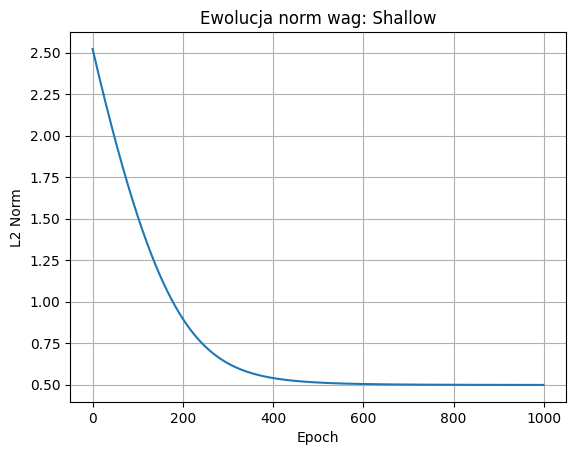

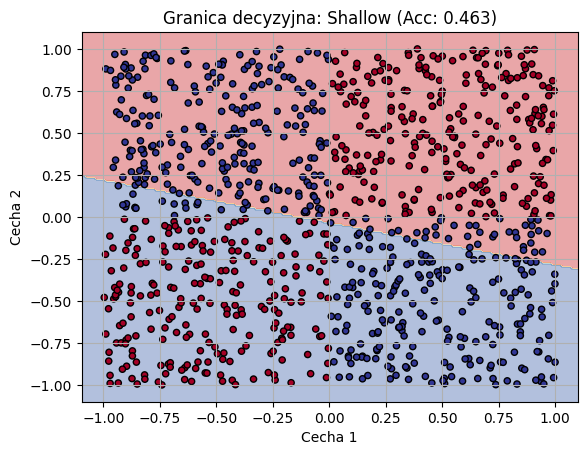


--- Wizualizacja wyników: Shallow_8 ---


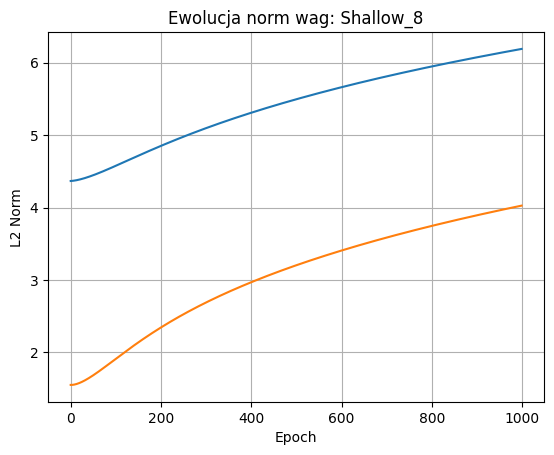

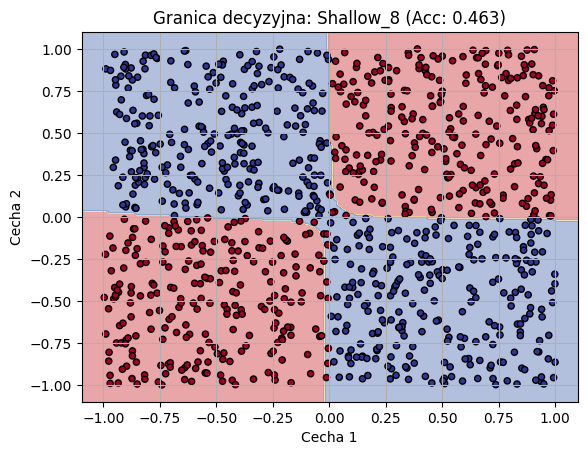


--- Wizualizacja wyników: Shallow_16 ---


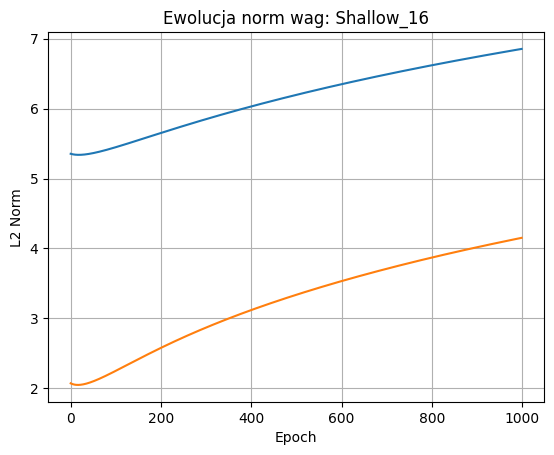

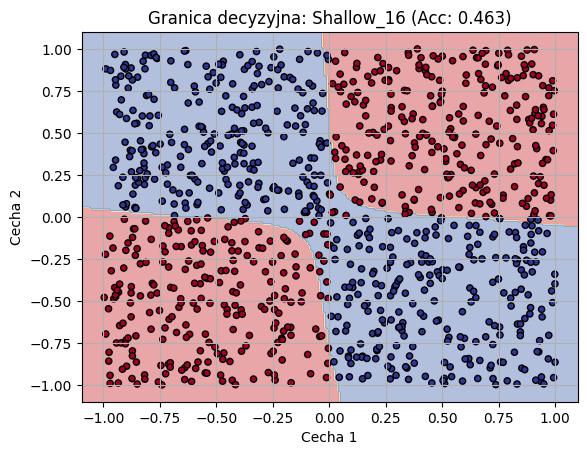


--- Wizualizacja wyników: Shallow_32 ---


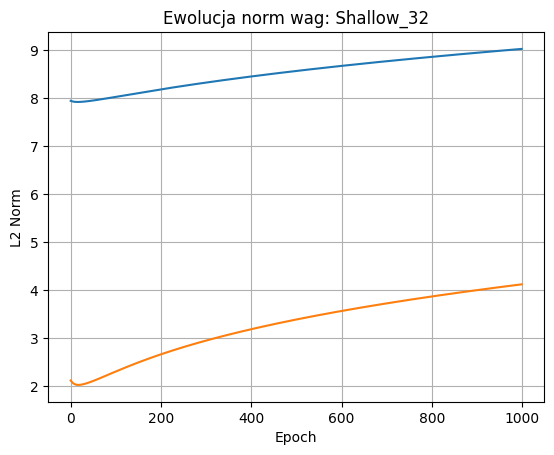

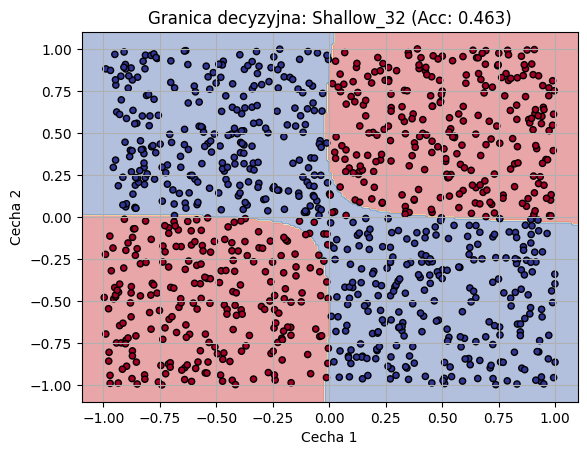


--- Wizualizacja wyników: Deep_8_8 ---


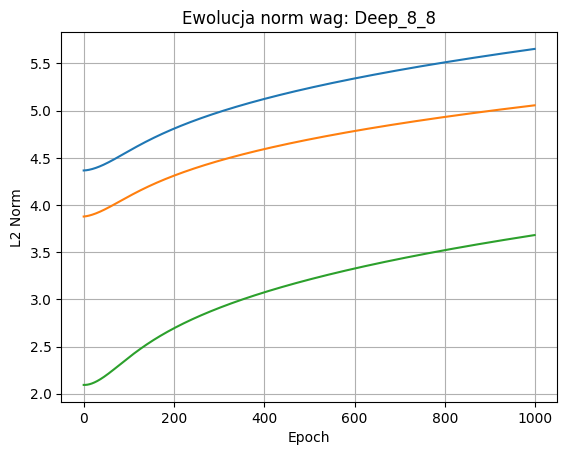

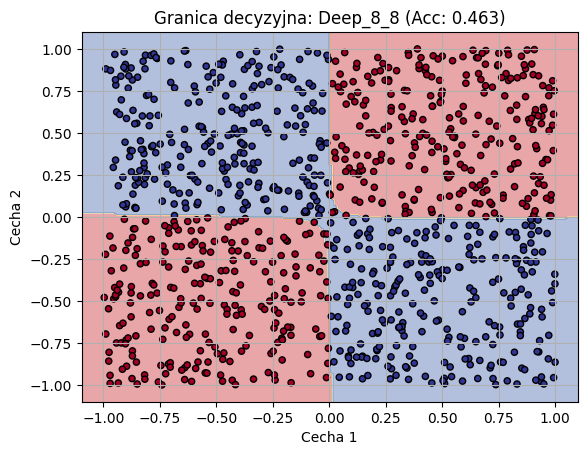


--- Wizualizacja wyników: Deep_16_8 ---


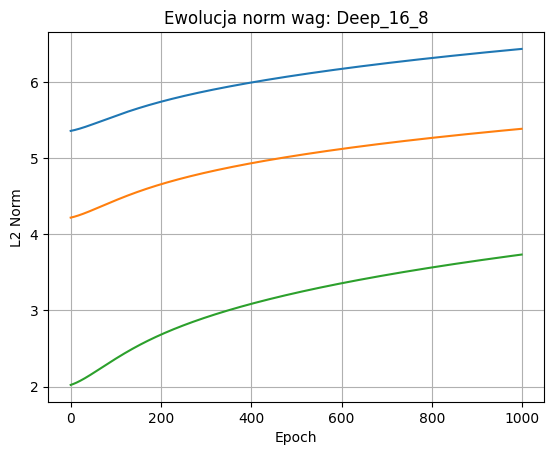

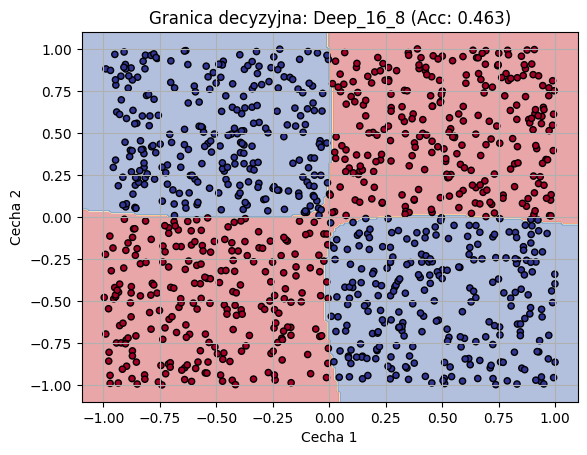


--- Wizualizacja wyników: Deep_16_16 ---


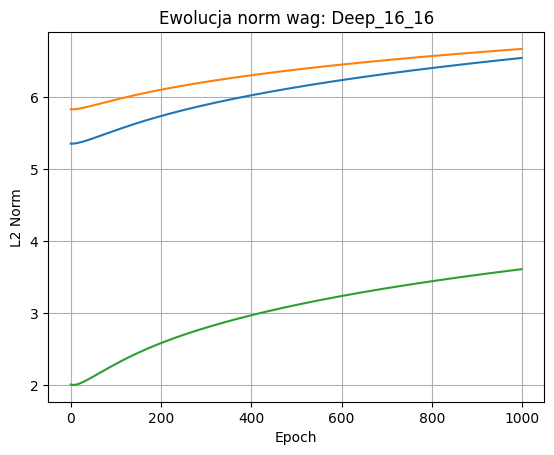

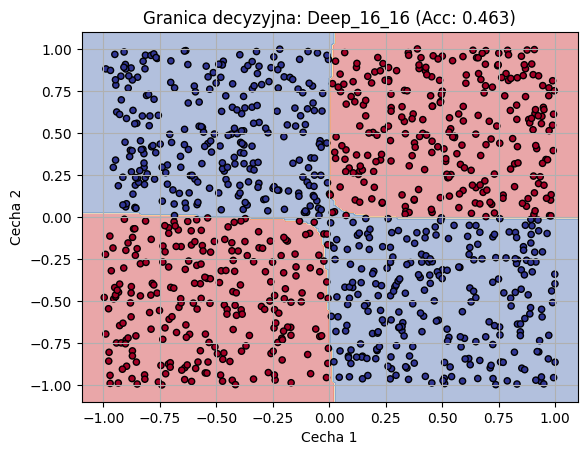


--- Wizualizacja wyników: Deep_32_64_64_32 ---


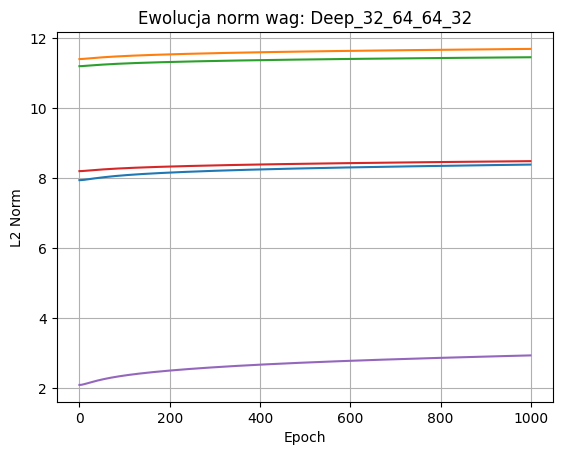

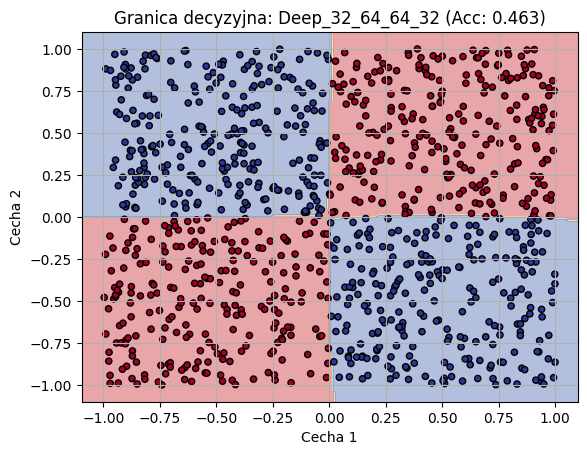

In [28]:
# --- 5.1. Porównanie krzywych błędu (Loss) ---
# ... (ten fragment już poprawiliśmy, używa 'accuracy' i jest ok)

# --- 5.2. Wizualizacja granic decyzyjnych i ewolucji wag ---
for name, res in all_results.items():
    print(f"\n--- Wizualizacja wyników: {name} ---")
    
    # Ewolucja wag (zawsze)
    plot_weights_together(
        res["weights"], 
        title=f"Ewolucja norm wag: {name}"
    )

    # Granice decyzyjne i inne wizualizacje (tylko dla 2D klasyfikacji)
    if TASK != "regression":
        # Granice decyzyjne
        if X.shape[1] == 2:
            plot_decision_boundary(
                res["model"], X, y, # Używamy pełnego zbioru X i y (nie Y_TARGET) do scatter plot w utils.py
                title=f"Granica decyzyjna: {name} (Acc: {res['accuracy']:.3f})"
            )
        else:
            print("Pominięto plot_decision_boundary: Wymaga 2 cech wejściowych.")
    
    # Wizualizacja dla Regresji 1D
    elif TASK == "regression" and X.shape[1] == 1:
        # Ponownie liczymy predykcje na zbiorze testowym do wyświetlenia
        preds_test = res["model"].predict(X_test)
        
        plot_predictions(
            y_test, preds_test, 
            title=f"Predykcje vs. Prawda: {name} (MSE: {res['accuracy']:.3f})"
        )